# Imports

In [63]:

import pandas as pd
import numpy as np
import sys
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sklearn.model_selection import train_test_split
from Autoencoder import Autoencoder 
import matplotlib.pyplot as plt
from KMeans import KMeans
from Metrics import silhouette_score_scratch
from Metrics import davies_bouldin_score
from Metrics import calinski_harabasz_score_scratch
from ExternalValidations import adjusted_rand_index
from ExternalValidations import normalized_mutual_information
from ExternalValidations import purity_score
from Metrics import wcss_score

# Data preparetion

In [64]:
data = pd.read_csv('../data/data.csv')
y = data['diagnosis'].map({'M': 1, 'B': 0}).values
data.drop(columns=['diagnosis', 'id','Unnamed: 32'], inplace=True, errors='ignore')
x = data.copy()
print(x.head())


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [65]:
x_train , x_temp= train_test_split(data, test_size = 0.299, random_state=42)
x_val, x_test = train_test_split(x_temp, test_size = 0.5, random_state=42)
print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (398, 30), Validation shape: (85, 30), Test shape: (86, 30)


### data standardization and normalization


In [66]:
# Standardize for pca kmeans and gmm
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
x_standardized = (x - mean) / (std + 1e-8) #add small value to avoid division by zero

In [67]:
# normalized data for autoencoder
min = np.min(x, axis=0)
max = np.max(x, axis=0)
x_normalized = (x - min) / (max - min + 1e-8) #add small value to avoid division by zero
x_normalized.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431016,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186815,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


### Experiment 5

In [68]:
architectures = {
    2:  [30, 25, 20, 15, 2, 15, 20, 25, 30],
    5:  [30, 25, 20, 15, 5, 15, 20, 25, 30],
    10: [30, 25, 20, 15, 10, 15, 20, 25, 30],
    15: [30, 26, 22, 18, 15, 18, 22, 26, 30], 
    20: [30, 28, 26, 24, 20, 24, 26, 28, 30]  # Wide layers to avoid crushing info before bottleneck
}

dim = [2, 5, 10, 15, 20]
results = []
all_loss_histories = {}
projections = {}
for size in dim:
    print(f"\n--- Testing Bottleneck Size: {size} ---")
    
    # Define Architecture: 30 -> 16 -> size -> 16 -> 30
    layer_sizes = architectures[size]
    activations = ['relu', 'relu', 'relu', 'tanh', 
               'relu', 'relu', 'relu', 'sigmoid']
    
    # Initialize and Train Autoencoder
    ae = Autoencoder(layer_sizes=layer_sizes, activations=activations)
    # Using small batch size for this dataset (569 samples)
    loss_history = ae.train(x_normalized.values, epochs=300)
    all_loss_histories[size] = loss_history
    
    # 3. Dimensionality Reduction
    X_latent = ae.get_latent_space(x_normalized.values)
    projections[size] = X_latent
    
    # 4. Clustering in Latent Space
    # k=2 because the dataset has 2 classes (Malignant/Benign)
    kmeans = KMeans(k=2, initialization_method='k-means++')
    kmeans.fit(X_latent)
    preds = kmeans.labels
    
    # 5. Calculate Metrics
    results.append({
        'Bottleneck': size,
        'Final MSE': loss_history[-1],
        'Silhouette': silhouette_score_scratch(X_latent, preds),
        'Davies-Bouldin': davies_bouldin_score(X_latent, preds),
        'Calinski-Harabasz': calinski_harabasz_score_scratch(X_latent, preds),
        'WCSS': wcss_score(X_latent, preds),
        'Adj-Rand-Index': adjusted_rand_index(y, preds),
        'NMI': normalized_mutual_information(y, preds),
        'Purity': purity_score(y, preds)
    })


--- Testing Bottleneck Size: 2 ---
Epoch 0, Loss: 0.0276, Learning Rate: 0.1000
Epoch 10, Loss: 0.0124, Learning Rate: 0.0909
Epoch 20, Loss: 0.0111, Learning Rate: 0.0833
Epoch 30, Loss: 0.0098, Learning Rate: 0.0769
Epoch 40, Loss: 0.0090, Learning Rate: 0.0714
Epoch 50, Loss: 0.0082, Learning Rate: 0.0667
Epoch 60, Loss: 0.0078, Learning Rate: 0.0625
Epoch 70, Loss: 0.0074, Learning Rate: 0.0588
Epoch 80, Loss: 0.0072, Learning Rate: 0.0556
Epoch 90, Loss: 0.0071, Learning Rate: 0.0526
Epoch 100, Loss: 0.0068, Learning Rate: 0.0500
Epoch 110, Loss: 0.0067, Learning Rate: 0.0476
Epoch 120, Loss: 0.0067, Learning Rate: 0.0455
Epoch 130, Loss: 0.0065, Learning Rate: 0.0435
Epoch 140, Loss: 0.0065, Learning Rate: 0.0417
Epoch 150, Loss: 0.0064, Learning Rate: 0.0400
Epoch 160, Loss: 0.0065, Learning Rate: 0.0385
Epoch 170, Loss: 0.0063, Learning Rate: 0.0370
Epoch 180, Loss: 0.0063, Learning Rate: 0.0357
Epoch 190, Loss: 0.0062, Learning Rate: 0.0345
Epoch 200, Loss: 0.0062, Learning R

In [69]:
res_2d = results[0] # The first size in our list was 2
plt.figure(figsize=(8, 6))
plt.scatter(res_2d['latent_data'][:, 0], res_2d['latent_data'][:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title('2D Latent Space Projection (Breast Cancer Dataset)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.colorbar(label='Class (0: Malignant, 1: Benign)')
plt.show()

# 6. Final Summary Table
print(f"\n{'Bottleneck':<10} | {'Reconstruction Loss':<20} | {'Inertia':<10}")
print("-" * 45)
for r in results:
    print(f"{r['bottleneck']:<10} | {r['reconstruction_loss']:<20.6f} | {r['latent_inertia']:<10.2f}")

KeyError: 'latent_data'

<Figure size 800x600 with 0 Axes>

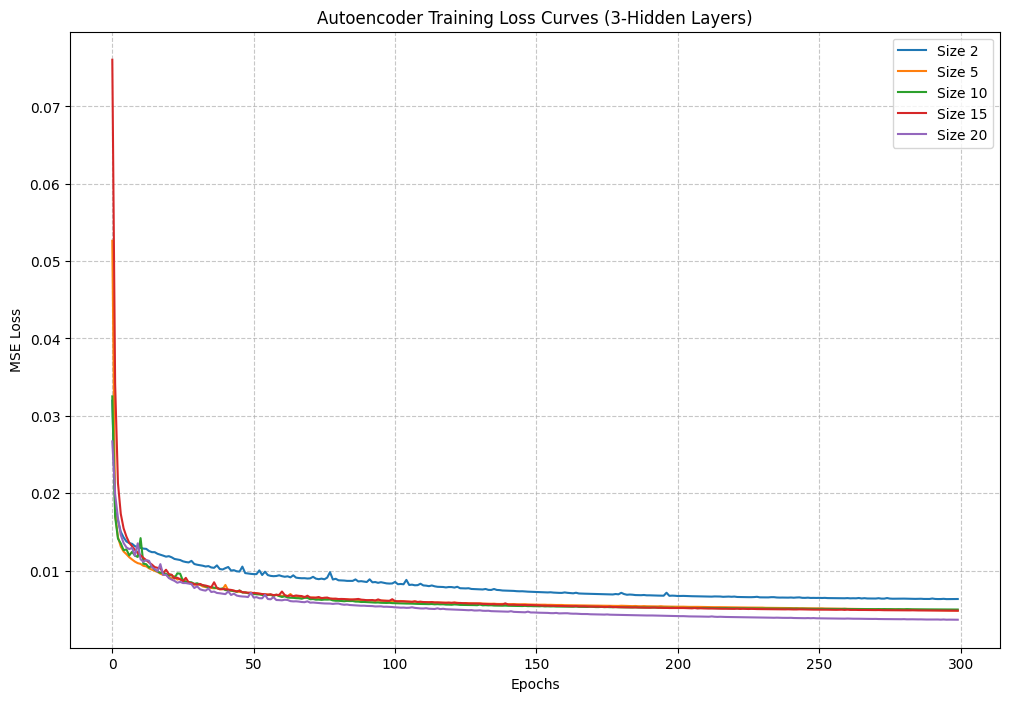

In [ ]:
plt.figure(figsize=(12, 8))
for size in dim:
    plt.plot(all_loss_histories[size], label=f'Size {size}')
plt.title('Autoencoder Training Loss Curves (3-Hidden Layers)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

Converged at iteration number 12.
Converged at iteration number 9.


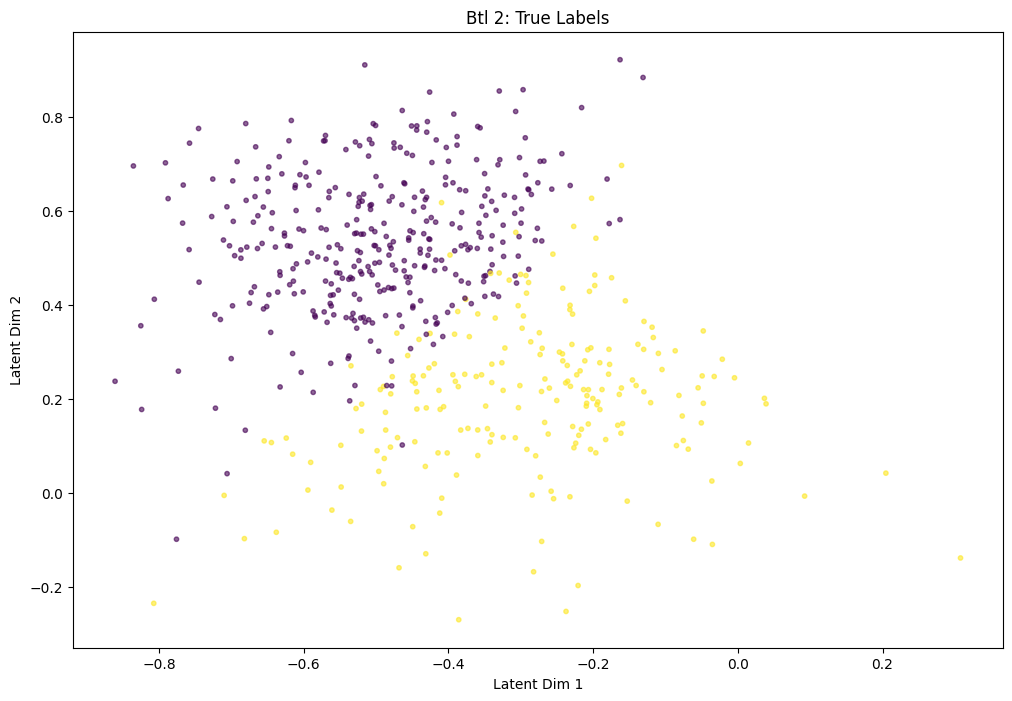

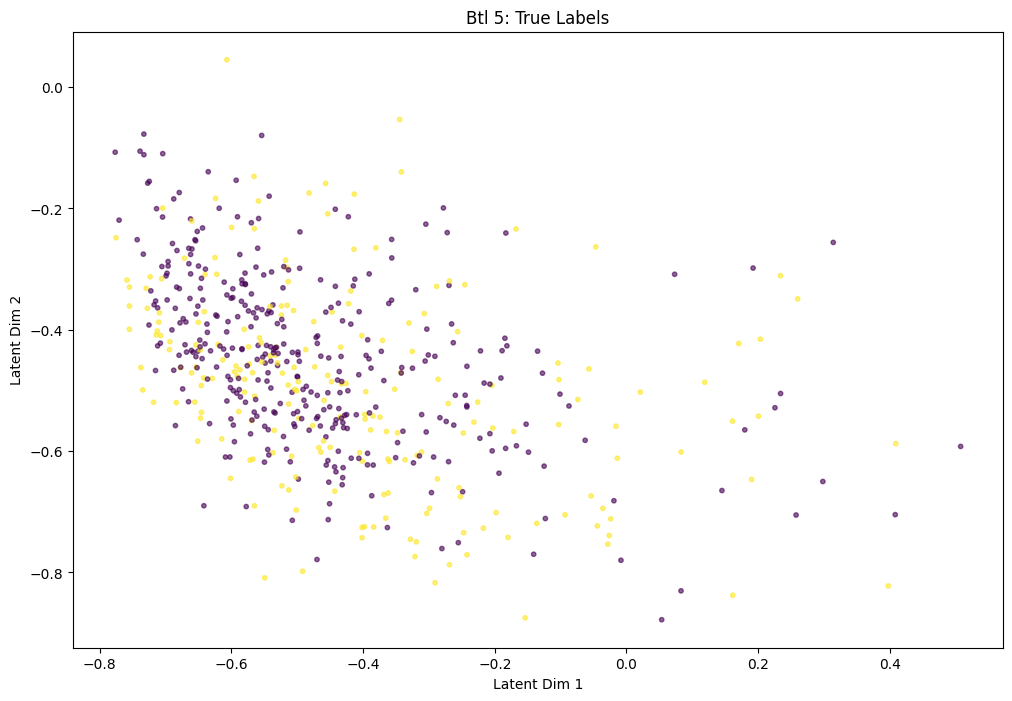

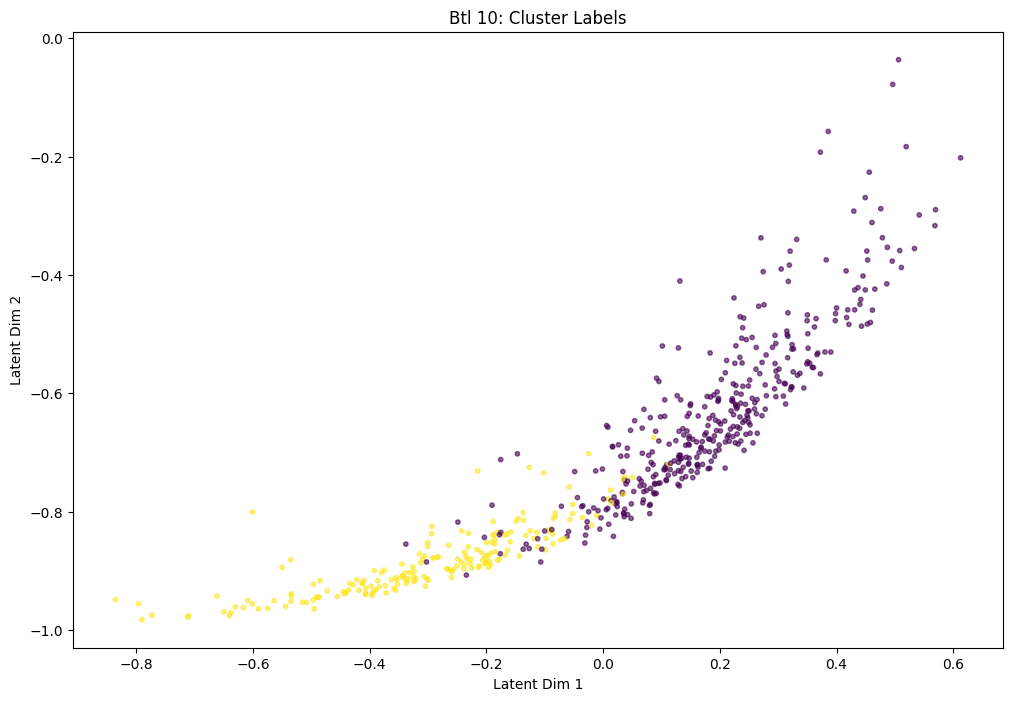

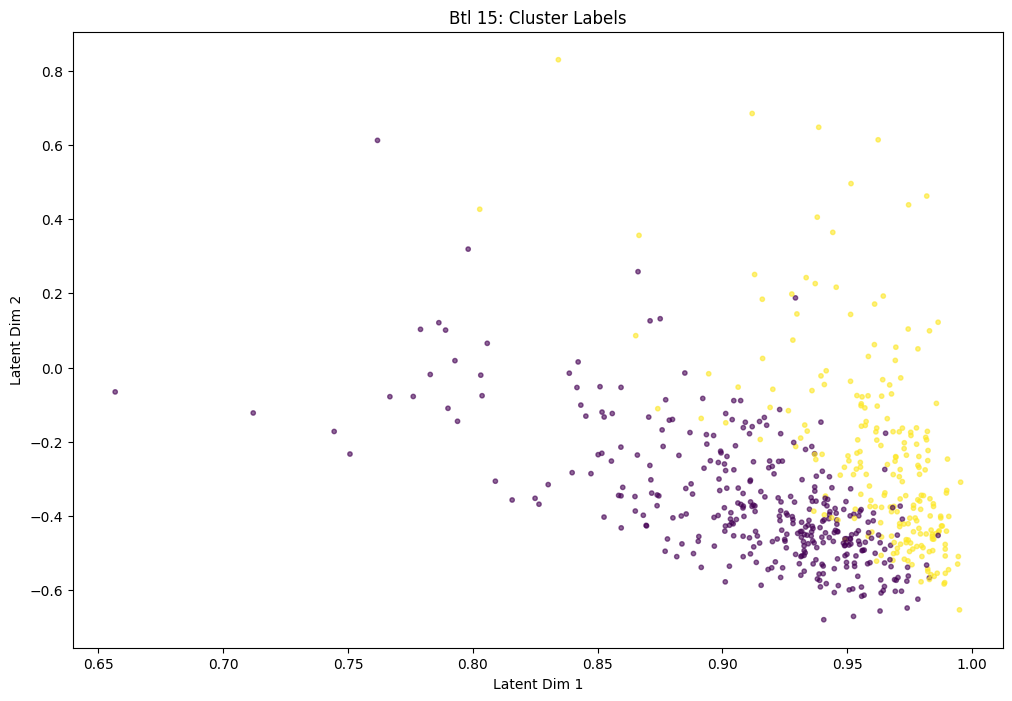

In [ ]:
display_sizes = [2, 5, 10, 15] # Select 4 sizes to fit the 3x4 grid logic
for i, size in enumerate(display_sizes):
    # Find the result dictionary for this specific bottleneck size
    res = next(item for item in results if item['Bottleneck'] == size)

    plt.figure(figsize=(12, 8))
    X_proj = projections[size]
    
    # We use 'y' (True labels) for the first two plots 
    # and 'preds' (Cluster labels) for the next two to match the logic
    if i < 2:
        colors = y  # True Labels
        title_suffix = "True Labels"
    else:
        # Re-run a quick fit or store labels in results_list during the loop
        # For this fix, we'll assume you added 'Labels' to results_list
        km_temp = KMeans(k=2)
        km_temp.fit(X_proj)
        colors = km_temp.labels
        title_suffix = "Cluster Labels"

    plt.scatter(X_proj[:, 0], X_proj[:, 1], c=colors, cmap='viridis', s=10, alpha=0.6)
    plt.title(f'Btl {size}: {title_suffix}')
    plt.xlabel('Latent Dim 1')
    plt.ylabel('Latent Dim 2')

Converged at iteration number 12.


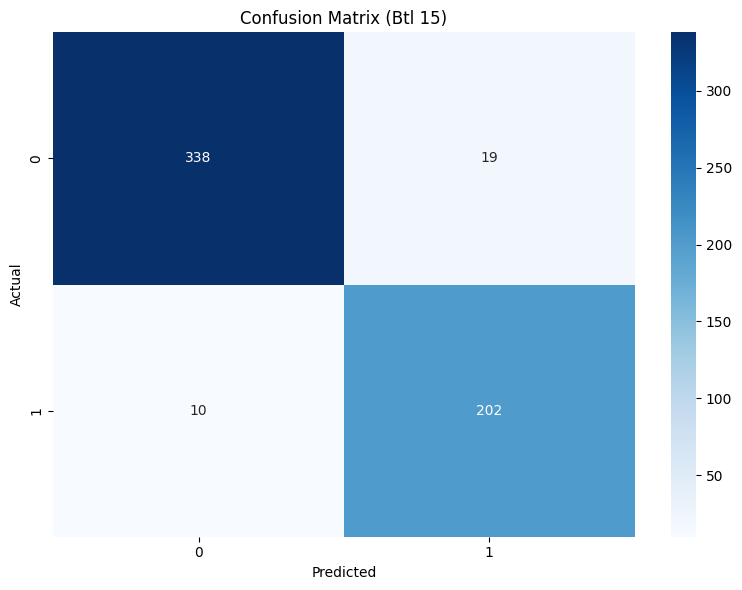

In [ ]:
results_df = pd.DataFrame(results).set_index('Bottleneck')
best_size = results_df['Adj-Rand-Index'].idxmax()
best_idx = dim.index(best_size)
best_latent = projections[best_size]
km_best = KMeans(k=2)
km_best.fit(best_latent)
cm = confusion_matrix(y, km_best.labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Btl {best_size})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()